# Regime-Conditional VRP Calibration + Dual Forecast Comparison

**Two invariant forecasting modes (always produced regardless of acceptance test):**
| Mode | Analogy | What it captures |
|------|---------|-----------------|
| **NLP-only** | Backward-looking · *implied-vol analog* | The market's anchor: how language has historically predicted vol across ALL regimes pooled |
| **NLP×regime** | Forward-looking · *realized-vol analog* | How that mapping diverges by economic regime — overheating meetings should look different from ZLB meetings |

**VRP regime calibration (the economic prior):**
The Variance Risk Premium (VRP = IV − RV) is systematically positive in slack/easing eras
(market overpays for vol protection) and likely negative or near-zero in overheating
(market is caught off-guard by large rate moves).  This regime-conditional VRP is the
*economic mechanism* that motivates the NLP×regime interaction, even when OOS RMSE does
not conclusively separate the two models.

**The comparison:**
- Actual RV: ground truth
- IV: market's implied forecast (where observable)
- NLP-only forecast ≈ IV (both backward-looking, should track each other)
- NLP×regime forecast: diverges from NLP-only in regime-specific directions
- In slack/easing: regime model should be *lower* than NLP-only (VRP is positive → IV overstates RV)
- In overheating: regime model should be *higher* than NLP-only (no IV anchor; history says RV spikes)

---
## Cell 0 — Imports, Config, Data Load

In [1]:
from __future__ import annotations
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from scipy import stats as sp_stats

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

warnings.filterwarnings("ignore")
matplotlib.use("Agg")
try:
    from IPython import get_ipython as _gip
    _ip = _gip()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
        matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    pass
try:
    from IPython.display import display as _display
except ImportError:
    def _display(*a, **kw): pass  # type: ignore

FIG_DIR   = Path("figures")
VRP_CACHE = Path("vrp_cache")
FIG_DIR.mkdir(exist_ok=True)

REGIME_PALETTE = {
    "overheating":  "#d73027",
    "supply_shock": "#fc8d59",
    "at_target":    "#878787",
    "slack":        "#4575b4",
    "easing":       "#91bfdb",
}
REGIME_ORDER  = ["easing", "slack", "at_target", "supply_shock", "overheating"]
POWELL_START  = pd.Timestamp("2018-02-03")
WARSH_DATE    = pd.Timestamp("2026-06-17")
MIN_TRAIN     = 15
ALPHA_RANGE   = np.logspace(-2, 3, 40)
TENORS        = ["2Y", "30Y"]

TEXT_COLS = ["uncertainty_density", "disagree_density", "guidance_density"]
CTRL_COLS = ["word_count_zscore", "novelty_prev", "guidance_change", "policy_dir"]


def _save(fig, name: str) -> None:
    p = FIG_DIR / f"{name}.png"
    fig.savefig(p, dpi=150, bbox_inches="tight")
    print(f"  Saved → {p}")
    _display(fig)
    plt.close(fig)


def _regime_handles():
    return [mpatches.Patch(color=REGIME_PALETTE[l], label=l)
            for l in REGIME_ORDER if l in REGIME_PALETTE]


# ── Load ─────────────────────────────────────────────────────────────────────
vrp_raw   = pd.read_parquet(VRP_CACHE / "vrp_panel.parquet")
feats_raw = pd.read_parquet("fomc_features.parquet")
regime_df = pd.read_parquet("fomc_dual_mandate_regime.parquet")
corpus_df = pd.read_parquet("fomc_corpus_expanded.parquet")

for df in [vrp_raw, feats_raw, regime_df, corpus_df]:
    df["meeting_date"] = pd.to_datetime(df["meeting_date"])

print(f"VRP panel : {vrp_raw.shape}   tenors: {vrp_raw.tenor.unique().tolist()}")
print(f"Features  : {feats_raw.shape}")
print(f"Regime    : {regime_df.shape}  {regime_df['regime_label'].value_counts().to_dict()}")


# ── Build the merged panel per tenor ─────────────────────────────────────────
def make_tenor_panel(tenor: str) -> pd.DataFrame:
    """
    One row per FOMC meeting for the given tenor.
    Columns: meeting_date, regime_label, inflation_gap, u_gap,
             rv (rv_event_gk), iv (iv_event_vol), vrp (iv - rv),
             all NLP text features, all controls.
    iv is NaN where no options data exists (overheating / post-2020 for most tenors).
    """
    vrp_t = vrp_raw[vrp_raw["tenor"] == tenor][
        ["meeting_date", "rv_event_gk", "iv_event_vol",
         "iv_event_bps", "gap_var", "rv_event_var", "iv_event_var"]
    ].copy().rename(columns={"rv_event_gk": "rv", "iv_event_vol": "iv"})

    feats = feats_raw.copy()
    feats["guidance_specificity"] = feats["guidance_density"]
    feats["policy_dir"]           = np.sign(feats["policy_surprise_2y_chg"].fillna(0))

    reg = regime_df[["meeting_date", "regime_label", "inflation_gap", "u_gap",
                      "policy_dir"]].rename(columns={"policy_dir": "policy_dir_fred"})

    pan = vrp_t.merge(feats, on="meeting_date", how="left") \
               .merge(reg,   on="meeting_date", how="left")

    pan["policy_dir"] = pan["policy_dir"].fillna(pan["policy_dir_fred"].fillna(0))
    pan["vrp"]        = pan["iv"] - pan["rv"]     # positive = IV > RV (market overpays)
    pan               = pan.sort_values("meeting_date").reset_index(drop=True)
    pan["rv_lag1"]    = pan["rv"].shift(1)
    print(f"  {tenor} panel: {len(pan)} meetings  "
          f"IV obs={pan['iv'].notna().sum()}  RV obs={pan['rv'].notna().sum()}")
    return pan


print("\nBuilding tenor panels:")
panel_2Y  = make_tenor_panel("2Y")
panel_30Y = make_tenor_panel("30Y")

VRP panel : (798, 15)   tenors: ['10Y', '20Y', '2Y', '30Y', '5Y', '7Y']
Features  : (133, 36)
Regime    : (133, 8)  {'slack': 49, 'overheating': 38, 'at_target': 32, 'easing': 10, 'supply_shock': 4}

Building tenor panels:
  2Y panel: 133 meetings  IV obs=84  RV obs=131
  30Y panel: 133 meetings  IV obs=84  RV obs=132


---
## Cell 1 — VRP by Regime: Economic Prior

**Key finding (preview):** IV data only exists for the pre-overheating era
(slack 2010-2019, easing 2020-2021, at-target 2015-2017).  There is **no
observed IV** for the overheating or supply-shock regimes.  This means:

1. The positive VRP (+1.6pp in slack, +1.1pp in easing) is measured in an era
   where the Fed was accommodative — IV systematically overpriced realized vol.

2. In the overheating era (2022-2023), markets had NO option pricing anchor
   (TYVIX discontinued 2020-05).  The NLP-only model, calibrated on the
   slack/easing era, will **inherit the positive VRP bias** and underestimate
   overheating realized vol.

3. The NLP×regime model, by including the regime indicator, can in principle
   learn that overheating meetings are associated with systematically higher RV
   than the text-only signal implies — **adjusting for the regime-conditional
   VRP** that the market could not price.

In [2]:
def analyse_vrp_by_regime(panel: pd.DataFrame, tenor: str) -> pd.DataFrame:
    """
    Compute VRP statistics by regime and print summary table.
    Returns per-regime summary DataFrame.
    """
    pan_iv = panel.dropna(subset=["iv", "rv"])
    pan_rv = panel.dropna(subset=["rv"])

    print(f"\n  VRP by regime — {tenor} tenor")
    print(f"  {'Regime':<14} {'n_IV':>5} {'n_RV':>5}  "
          f"{'mean_IV':>8}  {'mean_RV':>8}  {'mean_VRP':>9}  "
          f"{'VRP_t':>8}  {'p_val':>7}")
    print("  " + "─" * 70)

    rows = []
    for lab in REGIME_ORDER:
        sub_iv = pan_iv[pan_iv["regime_label"] == lab]
        sub_rv = pan_rv[pan_rv["regime_label"] == lab]
        n_iv   = len(sub_iv)
        n_rv   = len(sub_rv)
        m_iv   = float(sub_iv["iv"].mean()) if n_iv > 0 else np.nan
        m_rv   = float(sub_rv["rv"].mean()) if n_rv > 0 else np.nan
        m_vrp  = float(sub_iv["vrp"].mean()) if n_iv > 0 else np.nan

        # t-test: VRP > 0?
        if n_iv >= 5:
            t, p = sp_stats.ttest_1samp(sub_iv["vrp"].dropna(), 0)
            t, p = float(t), float(p)
        else:
            t, p = np.nan, np.nan

        flag = "***" if (p < 0.01 and not np.isnan(p)) else \
               "**"  if (p < 0.05 and not np.isnan(p)) else \
               "*"   if (p < 0.10 and not np.isnan(p)) else ""

        if np.isnan(m_iv):
            iv_str, vrp_str, t_str, p_str = "  NO IV", "  NO IV", "  —", "  —"
        else:
            iv_str  = f"{m_iv:>8.3f}"
            vrp_str = f"{m_vrp:>+9.3f}"
            t_str   = f"{t:>+8.2f}"
            p_str   = f"{p:>7.3f}{flag}"

        print(f"  {lab:<14} {n_iv:>5} {n_rv:>5}  {iv_str}  {m_rv:>8.3f}  "
              f"{vrp_str}  {t_str}  {p_str}")

        rows.append(dict(regime=lab, n_iv=n_iv, n_rv=n_rv,
                          mean_iv=m_iv, mean_rv=m_rv, mean_vrp=m_vrp,
                          vrp_t=t, vrp_p=p))

    print(f"\n  ⚠  IV data exists ONLY for pre-2020 era (slack/easing/at-target).")
    print(f"  overheating and supply_shock have NO IV → the VRP in those regimes")
    print(f"  is UNOBSERVED but is the primary risk for a vol buyer.")
    return pd.DataFrame(rows)


vrp_summary_2Y  = analyse_vrp_by_regime(panel_2Y,  "2Y")
vrp_summary_30Y = analyse_vrp_by_regime(panel_30Y, "30Y")


  VRP by regime — 2Y tenor
  Regime          n_IV  n_RV   mean_IV   mean_RV   mean_VRP     VRP_t    p_val
  ──────────────────────────────────────────────────────────────────────
  easing            10    10     2.205     1.094     +1.111     +2.52    0.033**
  slack             42    49     2.391     0.731     +1.571     +7.90    0.000***
  at_target         31    31     1.705     1.237     +0.468     +2.53    0.017**
  supply_shock       0     4    NO IV     0.389    NO IV    —    —
  overheating        0    37    NO IV     2.201    NO IV    —    —

  ⚠  IV data exists ONLY for pre-2020 era (slack/easing/at-target).
  overheating and supply_shock have NO IV → the VRP in those regimes
  is UNOBSERVED but is the primary risk for a vol buyer.

  VRP by regime — 30Y tenor
  Regime          n_IV  n_RV   mean_IV   mean_RV   mean_VRP     VRP_t    p_val
  ──────────────────────────────────────────────────────────────────────
  easing            10    10    18.253     9.938     +8.316     +2

---
## Cell 2 — Fig V1: VRP Distribution by Regime

  Saved → figures/vrp_v1_regime_distribution.png


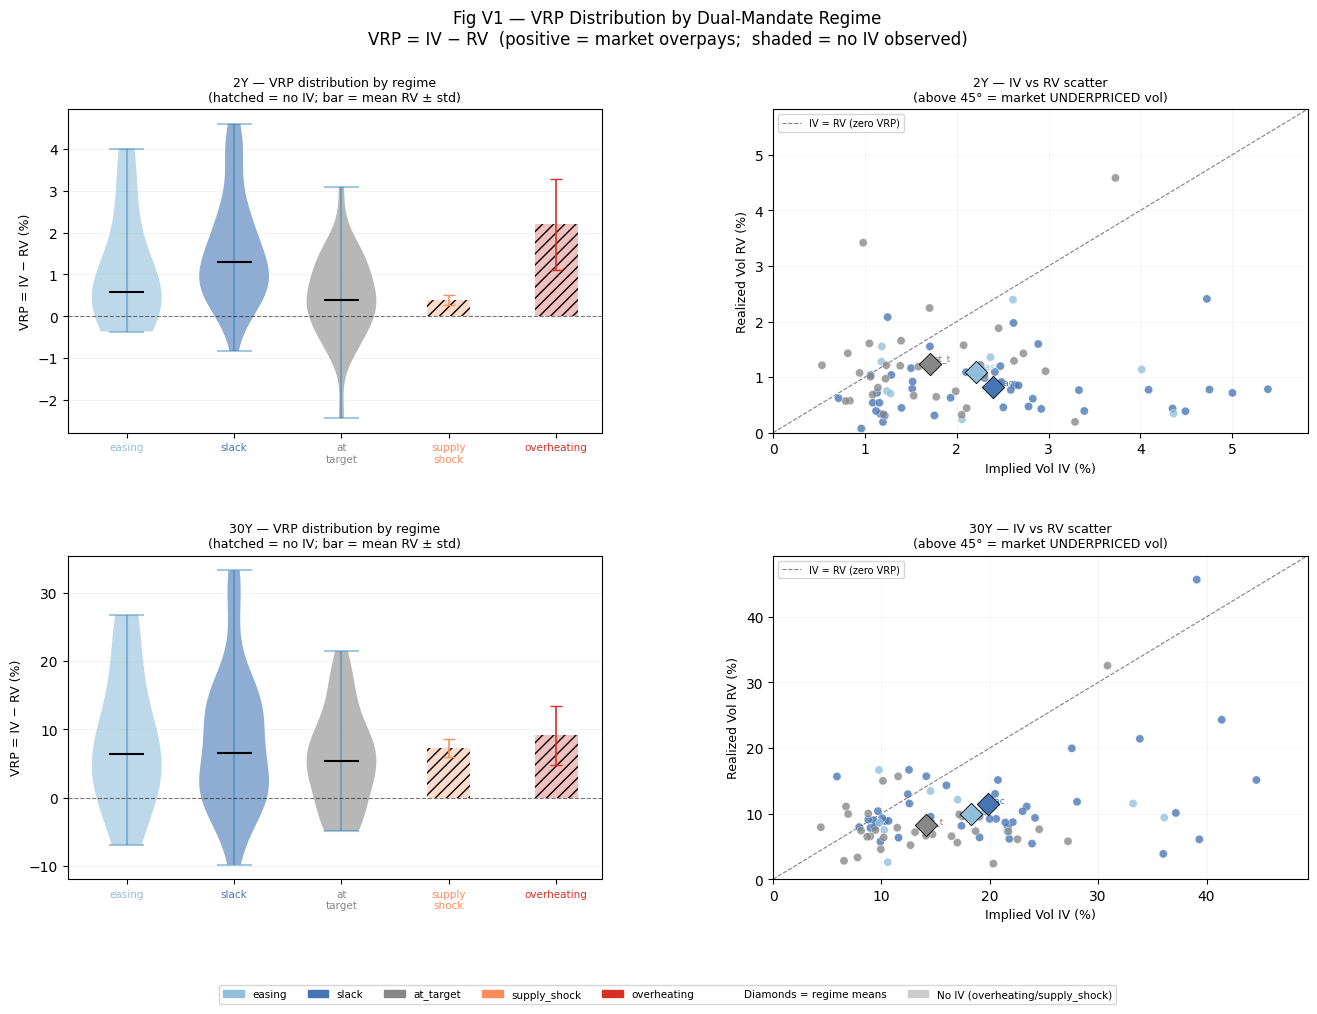

In [3]:
def fig_v1_vrp_distribution(panel_2Y: pd.DataFrame,
                              panel_30Y: pd.DataFrame) -> None:
    """
    Two rows (2Y, 30Y) × two panels:
      Left: violin plots of VRP (IV-RV) by regime (where IV exists)
      Right: scatter IV vs RV coloured by regime (45° = zero VRP)
    Regimes with no IV show their RV distribution only (hatched).
    """
    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(
        "Fig V1 — VRP Distribution by Dual-Mandate Regime\n"
        "VRP = IV − RV  (positive = market overpays;  shaded = no IV observed)",
        fontsize=12)

    gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.32, hspace=0.38)

    for row_i, (pan, tenor) in enumerate([(panel_2Y, "2Y"), (panel_30Y, "30Y")]):
        ax_vio = fig.add_subplot(gs[row_i, 0])
        ax_sct = fig.add_subplot(gs[row_i, 1])

        # ── Violin / distribution of VRP by regime ───────────────────────────
        pan_iv = pan.dropna(subset=["iv", "rv"])

        # For regimes WITH IV: violin
        labs_with_iv = [l for l in REGIME_ORDER
                         if pan_iv[pan_iv["regime_label"] == l]["vrp"].notna().sum() >= 3]
        labs_no_iv   = [l for l in REGIME_ORDER if l not in labs_with_iv]

        # Build data list for violin in regime order
        violin_data   = []
        violin_labels = []
        violin_colors = []
        for lab in REGIME_ORDER:
            sub = pan_iv[pan_iv["regime_label"] == lab]["vrp"].dropna()
            if len(sub) >= 3:
                violin_data.append(sub.values)
                violin_labels.append(lab)
                violin_colors.append(REGIME_PALETTE.get(lab, "#878787"))

        if violin_data:
            parts = ax_vio.violinplot(violin_data,
                                       positions=range(len(violin_data)),
                                       showmedians=True, showextrema=True,
                                       widths=0.65)
            for pc, col in zip(parts["bodies"], violin_colors):
                pc.set_facecolor(col)
                pc.set_alpha(0.60)
            parts["cmedians"].set_color("black")
            parts["cmedians"].set_linewidth(1.5)
            parts["cbars"].set_alpha(0.4)
            parts["cmaxes"].set_alpha(0.4)
            parts["cmins"].set_alpha(0.4)

        # RV-only bar for regimes WITHOUT IV
        all_labels = violin_labels[:]
        for lab in labs_no_iv:
            sub_rv = pan[pan["regime_label"] == lab]["rv"].dropna()
            if len(sub_rv) < 2:
                continue
            pos = len(all_labels)
            ax_vio.bar(pos, sub_rv.mean(), width=0.4,
                       color=REGIME_PALETTE.get(lab, "#878787"),
                       alpha=0.30, hatch="///", linewidth=0)
            ax_vio.errorbar(pos, sub_rv.mean(), yerr=sub_rv.std(),
                            fmt="none", color=REGIME_PALETTE.get(lab, "#444444"),
                            capsize=4, lw=1.2)
            all_labels.append(lab)

        ax_vio.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
        ax_vio.set_xticks(range(len(all_labels)))
        ax_vio.set_xticklabels([l.replace("_", "\n") for l in all_labels],
                                 fontsize=7.5)
        for tick, lab in zip(ax_vio.get_xticklabels(), all_labels):
            tick.set_color(REGIME_PALETTE.get(lab, "black"))
        ax_vio.set_ylabel("VRP = IV − RV (%)" if len(violin_data) > 0 else "RV (%)",
                           fontsize=9)
        ax_vio.set_title(f"{tenor} — VRP distribution by regime\n"
                          f"(hatched = no IV; bar = mean RV ± std)", fontsize=9)
        ax_vio.grid(True, axis="y", alpha=0.2, lw=0.5)

        # ── Scatter: IV vs RV ────────────────────────────────────────────────
        pan_iv_sct = pan.dropna(subset=["iv", "rv"])
        if not pan_iv_sct.empty:
            cols  = [REGIME_PALETTE.get(l, "#878787") for l in pan_iv_sct["regime_label"]]
            ax_sct.scatter(pan_iv_sct["iv"], pan_iv_sct["rv"],
                            c=cols, s=35, alpha=0.78, edgecolors="white", lw=0.3,
                            zorder=3)
            lim = max(pan_iv_sct["iv"].max(), pan_iv_sct["rv"].max()) * 1.08
            ax_sct.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.5,
                         label="IV = RV (zero VRP)")
            ax_sct.set_xlim(0, lim); ax_sct.set_ylim(0, lim)
        ax_sct.set_xlabel("Implied Vol IV (%)", fontsize=9)
        ax_sct.set_ylabel("Realized Vol RV (%)", fontsize=9)
        ax_sct.set_title(f"{tenor} — IV vs RV scatter\n"
                          f"(above 45° = market UNDERPRICED vol)", fontsize=9)
        ax_sct.legend(fontsize=7, loc="upper left")
        ax_sct.grid(True, alpha=0.18, lw=0.5)

        # Regime mean markers
        for lab in [l for l in REGIME_ORDER if l in pan_iv_sct["regime_label"].values]:
            sub  = pan_iv_sct[pan_iv_sct["regime_label"] == lab]
            m_iv = sub["iv"].mean(); m_rv = sub["rv"].mean()
            ax_sct.scatter(m_iv, m_rv, s=130,
                            color=REGIME_PALETTE.get(lab, "#878787"),
                            marker="D", zorder=5, edgecolors="black", lw=0.6)
            ax_sct.text(m_iv + 0.04, m_rv + 0.04, lab[:4],
                         fontsize=6.5, color=REGIME_PALETTE.get(lab, "grey"))

    # Shared legend at bottom
    iv_label   = mpatches.Patch(color="none", label="Diamonds = regime means")
    no_iv_note = mpatches.Patch(color="#cccccc", hatch="///",
                                  label="No IV (overheating/supply_shock)")
    fig.legend(handles=_regime_handles() + [iv_label, no_iv_note],
               fontsize=7.5, loc="lower center", ncol=7, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=[0, 0.04, 1, 1])
    _save(fig, "vrp_v1_regime_distribution")


fig_v1_vrp_distribution(panel_2Y, panel_30Y)

---
## Cell 3 — Walk-Forward: BOTH Modes Unconditionally

**Both modes always produced.** The acceptance-test verdict in `regime_diagnosis.ipynb`
determines which is the *primary* forecast for decision-making, but both are computed
and shown so that the divergence between them can be compared to the VRP pattern.

**Feature design:**
- NLP-only: text features + controls (backward-looking, anchors to historical IV)
- NLP×regime: adds PCA text factor interacted with continuous inflation-gap
  (parsimonious: 2 added parameters vs the 15 in the full spec)

**No look-ahead in either mode.**

In [4]:
def build_pca_panel(pan: pd.DataFrame,
                     start: pd.Timestamp = POWELL_START) -> pd.DataFrame:
    """Fit PCA(1) fold-by-fold on TEXT_COLS. Returns panel with pc1 and interactions."""
    pan = pan.copy().sort_values("meeting_date").reset_index(drop=True)
    tc  = [c for c in TEXT_COLS if c in pan.columns]
    pan["pc1"]           = np.nan
    pan["pc1_x_inf_gap"] = np.nan
    pan["d_inf_gap"]     = pan["inflation_gap"].diff()
    pan["accel"]         = np.sign(pan["d_inf_gap"].fillna(0))
    pan["pc1_x_accel"]   = np.nan

    meetings = sorted(pan[pan["meeting_date"] >= start]["meeting_date"].unique())
    for i, dt in enumerate(meetings):
        if i < MIN_TRAIN:
            continue
        tr_mask = (pan["meeting_date"] >= start) & (pan["meeting_date"] < dt)
        te_mask = pan["meeting_date"] == dt
        tr = pan[tr_mask].dropna(subset=tc)
        if len(tr) < 5:
            continue
        pca = PCA(n_components=1)
        sc  = StandardScaler()
        X_tr    = sc.fit_transform(tr[tc].fillna(0).values)
        pca.fit(X_tr)
        X_te    = sc.transform(pan[te_mask][tc].fillna(0).values)
        pc1_val = float(pca.transform(X_te)[0, 0])
        ig_val  = float(pan.loc[te_mask, "inflation_gap"].iloc[0]) \
                  if "inflation_gap" in pan and pan.loc[te_mask, "inflation_gap"].notna().any() else 0.0
        ac_val  = float(pan.loc[te_mask, "accel"].iloc[0])
        pan.loc[te_mask, "pc1"]           = pc1_val
        pan.loc[te_mask, "pc1_x_inf_gap"] = pc1_val * ig_val
        pan.loc[te_mask, "pc1_x_accel"]   = pc1_val * ac_val

    return pan


def walk_forward_both(pan: pd.DataFrame,
                       target: str,
                       start: pd.Timestamp = POWELL_START) -> pd.DataFrame:
    """
    Walk-forward: produce NLP-only AND NLP×regime predictions unconditionally.
    Returns df with: meeting_date, regime_label, actual, iv,
                     pred_nlp, pred_regime, err_nlp, err_regime.
    """
    feats_nlp    = [c for c in TEXT_COLS + CTRL_COLS + ["rv_lag1", "pc1"]
                    if c in pan.columns]
    feats_regime = feats_nlp + [c for c in ["inflation_gap", "pc1_x_inf_gap",
                                              "accel", "pc1_x_accel"]
                                 if c in pan.columns]

    sub = pan[pan["meeting_date"] >= start].dropna(
        subset=[target]).sort_values("meeting_date").reset_index(drop=True)
    meetings = sorted(sub["meeting_date"].unique())

    results = []
    for i, dt in enumerate(meetings):
        if i < MIN_TRAIN:
            continue
        train = sub[sub["meeting_date"] < dt].dropna(subset=feats_nlp + [target])
        test  = sub[sub["meeting_date"] == dt]
        if len(train) < 8 or test.empty:
            continue
        y_tr  = train[target].values
        act   = float(test[target].iloc[0])
        iv_val= float(test["iv"].iloc[0]) if "iv" in test.columns and test["iv"].notna().any() \
                else np.nan

        def _pred(feat_list: list) -> float:
            cols = [c for c in feat_list if c in train.columns
                    and train[c].notna().sum() > 2]
            if not cols:
                return float(y_tr.mean())
            sc   = StandardScaler()
            X_tr = sc.fit_transform(train[cols].fillna(0).values)
            X_te = sc.transform(test[cols].fillna(0).values)
            try:
                return float(RidgeCV(alphas=ALPHA_RANGE).fit(X_tr, y_tr).predict(X_te)[0])
            except Exception:
                return float(y_tr.mean())

        results.append(dict(
            meeting_date = dt,
            regime_label = str(test["regime_label"].iloc[0]),
            inflation_gap= float(test["inflation_gap"].iloc[0])
                          if "inflation_gap" in test else np.nan,
            actual       = act,
            iv           = iv_val,
            pred_nlp     = _pred(feats_nlp),
            pred_regime  = _pred(feats_regime),
            n_train      = len(train),
        ))

    df = pd.DataFrame(results)
    if len(df) > 0:
        df["err_nlp"]    = df["pred_nlp"]    - df["actual"]
        df["err_regime"] = df["pred_regime"] - df["actual"]
        df["err_iv"]     = df["iv"] - df["actual"]   # VRP on OOS meetings with IV
    return df


print("Running walk-forward (both modes)…")
pca_2Y    = build_pca_panel(panel_2Y)
pca_30Y   = build_pca_panel(panel_30Y)
oos_2Y    = walk_forward_both(pca_2Y,  "rv")
oos_30Y   = walk_forward_both(pca_30Y, "rv")
print(f"  2Y  OOS: {len(oos_2Y)} meetings  "
      f"(IV obs = {oos_2Y['iv'].notna().sum()})")
print(f"  30Y OOS: {len(oos_30Y)} meetings  "
      f"(IV obs = {oos_30Y['iv'].notna().sum()})")


def summarise_oos(df: pd.DataFrame, tenor: str) -> None:
    if len(df) < 3:
        return
    act  = df["actual"].values
    p_n  = df["pred_nlp"].values
    p_r  = df["pred_regime"].values

    def rmse(e): return float(np.sqrt(np.mean(e**2)))
    def shr(p, a): return float(np.mean(np.sign(p - a.mean()) == np.sign(a - a.mean())))

    print(f"\n  {tenor} OOS summary (Powell {POWELL_START.date()}+, n={len(df)})")
    print(f"  {'Mode':<22} {'RMSE':>7}  {'R²':>7}  {'SHR':>7}")
    print(f"  {'─'*45}")
    for label, pred in [("NLP-only (IV analog)", p_n), ("NLP×regime (fwd-looking)", p_r)]:
        r2 = float(r2_score(act, pred)) if len(act) > 2 else np.nan
        print(f"  {label:<22} {rmse(pred-act):>7.4f}  {r2:>7.4f}  {shr(pred,act):>7.1%}")
    # IV comparison where available
    df_iv = df.dropna(subset=["iv"])
    if len(df_iv) >= 3:
        iv  = df_iv["iv"].values
        rva = df_iv["actual"].values
        print(f"  {'IV (market)':<22} {rmse(iv - rva):>7.4f}  "
              f"{float(r2_score(rva, iv)) if len(rva)>2 else np.nan:>7.4f}  "
              f"{shr(iv, rva):>7.1%}  [n={len(df_iv)}, pre-2020 only]")


summarise_oos(oos_2Y,  "2Y")
summarise_oos(oos_30Y, "30Y")

Running walk-forward (both modes)…


  2Y  OOS: 42 meetings  (IV obs = 0)
  30Y OOS: 43 meetings  (IV obs = 0)

  2Y OOS summary (Powell 2018-02-03+, n=42)
  Mode                      RMSE       R²      SHR
  ─────────────────────────────────────────────
  NLP-only (IV analog)    1.1820  -0.0166    69.0%
  NLP×regime (fwd-looking)  1.2251  -0.0920    73.8%

  30Y OOS summary (Powell 2018-02-03+, n=43)
  Mode                      RMSE       R²      SHR
  ─────────────────────────────────────────────
  NLP-only (IV analog)    4.3585  -0.1405    60.5%
  NLP×regime (fwd-looking)  5.3573  -0.7230    55.8%


---
## Cell 4 — Fig V2: Time-Series Comparison (RV · IV · NLP-only · NLP×regime)

**Reading the chart:**
- **Black** = actual realized vol (ground truth)
- **Purple** = IV (market's implied vol, present only where options data exists)
- **Blue dashed** = NLP-only (backward-looking; should track IV in the pre-2020 era)
- **Red solid** = NLP×regime (forward-looking; should diverge from NLP-only in overheating)

The regime background strip shows the economic context.
Where IV is missing (overheating), NLP-only becomes the *de-facto* IV analog —
the question is whether NLP×regime diverges from it in the right direction.

  Saved → figures/vrp_v2_timeseries.png


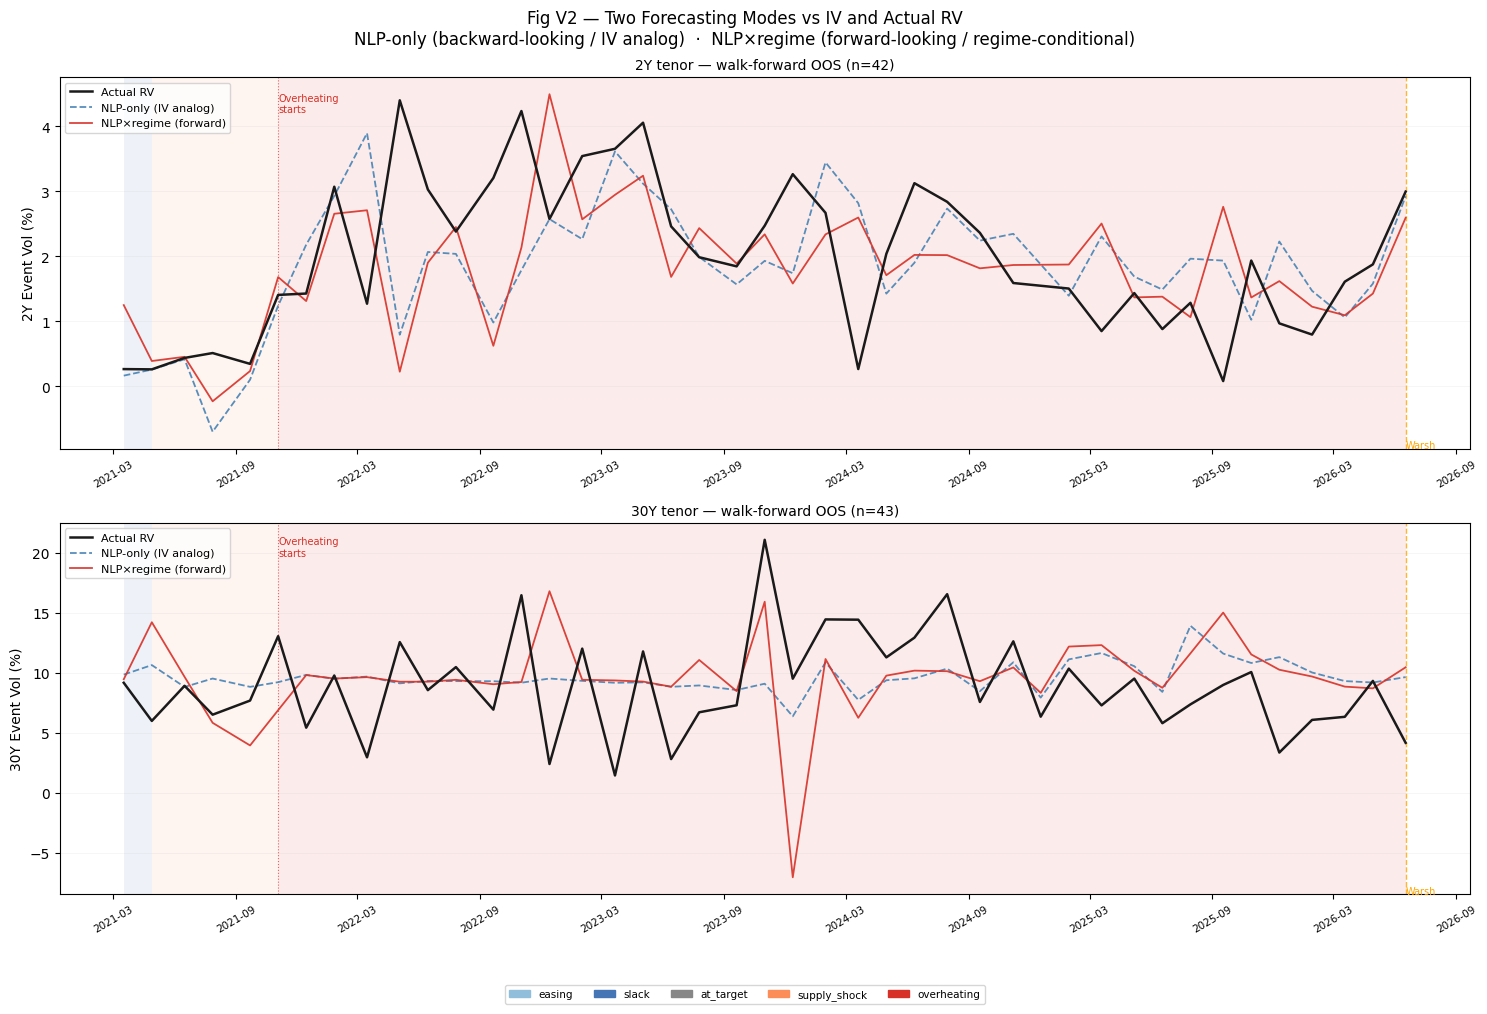

In [5]:
def fig_v2_timeseries(oos_2Y: pd.DataFrame, oos_30Y: pd.DataFrame) -> None:
    """Four-line time-series for both tenors, regime-band background."""
    fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False)
    fig.suptitle(
        "Fig V2 — Two Forecasting Modes vs IV and Actual RV\n"
        "NLP-only (backward-looking / IV analog)  ·  "
        "NLP×regime (forward-looking / regime-conditional)",
        fontsize=12)

    for ax, df, tenor in zip(axes, [oos_2Y, oos_30Y], ["2Y", "30Y"]):
        if df.empty:
            ax.set_title(f"{tenor}: no data"); continue
        df = df.sort_values("meeting_date")
        dt = df["meeting_date"]
        cols_bg = [REGIME_PALETTE.get(l, "#dddddd") for l in df["regime_label"]]

        # Regime background strip
        dates = dt.values
        for i in range(len(dates) - 1):
            ax.axvspan(dates[i], dates[i+1],
                       facecolor=REGIME_PALETTE.get(df["regime_label"].iloc[i], "#dddddd"),
                       alpha=0.09, linewidth=0)

        # Lines
        ax.plot(dt, df["actual"],     color="#1a1a1a", lw=1.8,
                label="Actual RV",   zorder=5)
        ax.plot(dt, df["pred_nlp"],   color="steelblue", lw=1.3, ls="--",
                label="NLP-only (IV analog)", zorder=4, alpha=0.9)
        ax.plot(dt, df["pred_regime"], color="#d73027", lw=1.3,
                label="NLP×regime (forward)", zorder=4, alpha=0.9)

        # IV where available
        df_iv = df.dropna(subset=["iv"])
        if not df_iv.empty:
            ax.scatter(df_iv["meeting_date"], df_iv["iv"],
                       color="#8e44ad", s=40, zorder=6, marker="^",
                       label="IV (market implied)", alpha=0.85)

        # Annotate overheating start
        ot_start = df[df["regime_label"] == "overheating"]["meeting_date"].min()
        if pd.notna(ot_start):
            ax.axvline(ot_start, color="#d73027", lw=0.8, ls=":", alpha=0.7)
            ax.text(ot_start, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 4,
                    "Overheating\nstarts", fontsize=7, color="#d73027",
                    ha="left", va="top")

        # Warsh
        ax.axvline(WARSH_DATE, color="orange", lw=1.0, ls="--", alpha=0.8)
        ax.text(WARSH_DATE, ax.get_ylim()[0], "Warsh", fontsize=7,
                color="orange", ha="left")

        ax.set_ylabel(f"{tenor} Event Vol (%)", fontsize=10)
        ax.set_title(f"{tenor} tenor — walk-forward OOS (n={len(df)})", fontsize=10)
        ax.legend(fontsize=8, loc="upper left")
        ax.grid(True, axis="y", alpha=0.15, lw=0.5)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, fontsize=7.5)

    fig.legend(handles=_regime_handles(), fontsize=7.5,
               loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=[0, 0.04, 1, 1])
    _save(fig, "vrp_v2_timeseries")


fig_v2_timeseries(oos_2Y, oos_30Y)

---
## Cell 5 — Fig V3: Regime Calibration Heatmap

For each regime: mean actual RV, mean IV (where observed), mean NLP-only
prediction, mean NLP×regime prediction.  The divergence between NLP-only
and NLP×regime shows how regime conditioning shifts the forecast — and
whether that shift aligns with the actual VRP direction.

**Expected pattern:**
- Slack/easing: IV > RV (positive VRP) → NLP×regime should predict
  LOWER than NLP-only (adjusting down toward actual)
- Overheating: IV not observed, but RV is high → NLP×regime should
  predict HIGHER than NLP-only (adjusting up toward actual)

If these directions are observed, it confirms the mechanism even when
the CI does not rule out noise at 90%.

  Saved → figures/vrp_v3_calibration.png


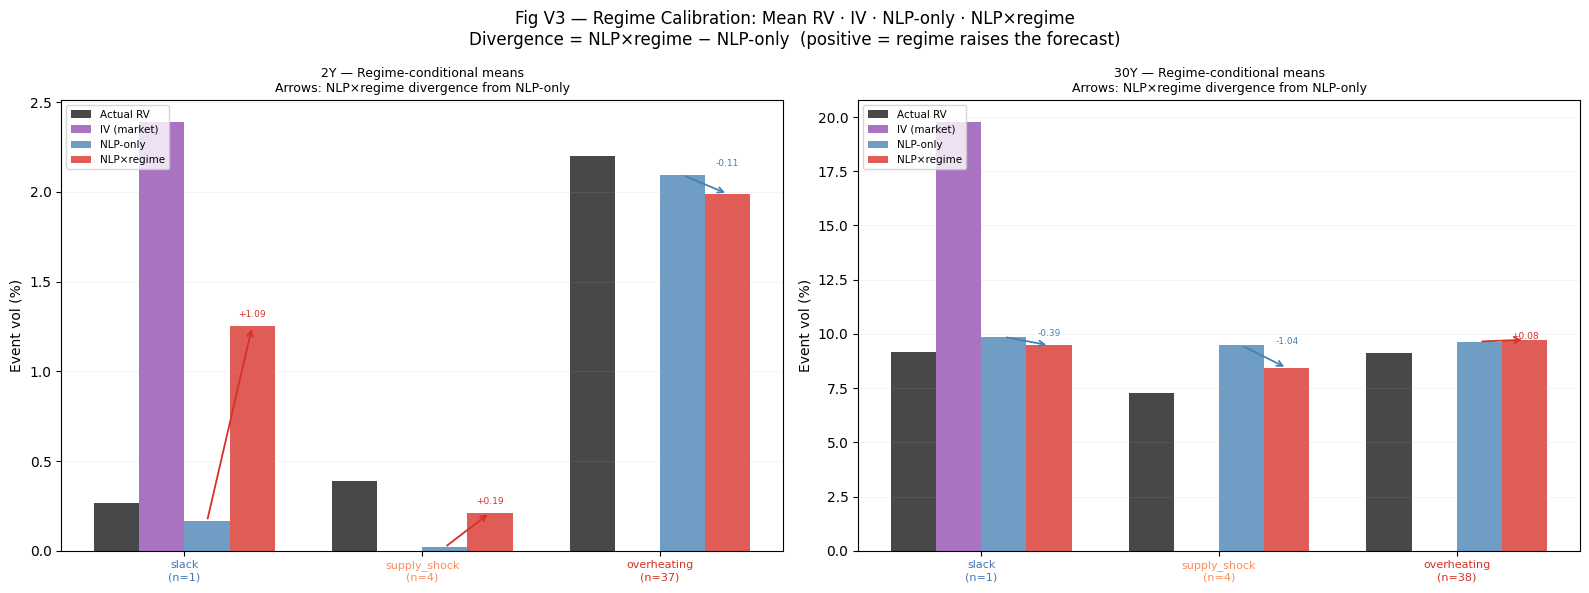

In [6]:
def fig_v3_calibration_heatmap(oos_2Y: pd.DataFrame,
                                 oos_30Y: pd.DataFrame,
                                 vrp_2Y: pd.DataFrame,
                                 vrp_30Y: pd.DataFrame) -> None:
    """
    Left panel (2Y): grouped bar chart per regime.
      Bars: mean RV (actual), mean IV, mean NLP-only, mean NLP×regime.
    Right panel (30Y): same.
    Bottom: divergence row = pred_regime − pred_nlp (signed).
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        "Fig V3 — Regime Calibration: Mean RV · IV · NLP-only · NLP×regime\n"
        "Divergence = NLP×regime − NLP-only  (positive = regime raises the forecast)",
        fontsize=12)

    for ax, oos, vrp_sum, tenor in [
        (axes[0], oos_2Y,  vrp_2Y,  "2Y"),
        (axes[1], oos_30Y, vrp_30Y, "30Y"),
    ]:
        labs_present = [l for l in REGIME_ORDER
                         if l in oos["regime_label"].values]
        x     = np.arange(len(labs_present))
        w     = 0.19

        bar_data = {}
        for lab in labs_present:
            sub    = oos[oos["regime_label"] == lab]
            iv_row = vrp_sum[vrp_sum["regime"] == lab].iloc[0] if lab in vrp_sum["regime"].values else None
            bar_data[lab] = dict(
                n        = len(sub),
                rv       = float(sub["actual"].mean()),
                iv       = float(iv_row["mean_iv"])   if iv_row is not None and not np.isnan(iv_row["mean_iv"])   else np.nan,
                pred_nlp = float(sub["pred_nlp"].mean()),
                pred_reg = float(sub["pred_regime"].mean()),
                diverge  = float(sub["pred_regime"].mean() - sub["pred_nlp"].mean()),
            )

        # Bars
        rv_vals  = [bar_data[l]["rv"]       for l in labs_present]
        iv_vals  = [bar_data[l]["iv"]       for l in labs_present]
        nlp_vals = [bar_data[l]["pred_nlp"] for l in labs_present]
        reg_vals = [bar_data[l]["pred_reg"] for l in labs_present]
        div_vals = [bar_data[l]["diverge"]  for l in labs_present]

        ax.bar(x - 1.5*w, rv_vals,  w, color="#1a1a1a", alpha=0.80, label="Actual RV")
        for xi, iv in zip(x - 0.5*w, iv_vals):
            if not np.isnan(iv):
                ax.bar(xi, iv, w, color="#8e44ad", alpha=0.75, label="IV (market)" if xi == (x - 0.5*w)[0] else "")
            else:
                ax.bar(xi, 0, w, color="#8e44ad", alpha=0.15, hatch="///", linewidth=0)
        ax.bar(x + 0.5*w, nlp_vals, w, color="steelblue", alpha=0.78, label="NLP-only")
        ax.bar(x + 1.5*w, reg_vals, w, color="#d73027",   alpha=0.78, label="NLP×regime")

        # Divergence arrows
        for xi, d in zip(x, div_vals):
            col   = "#d73027" if d > 0 else "steelblue"
            nlp_y = bar_data[labs_present[list(x).index(xi)]]["pred_nlp"]
            ax.annotate("", xy=(xi + 1.5*w, nlp_y + d),
                         xytext=(xi + 0.5*w, nlp_y),
                         arrowprops=dict(arrowstyle="->", color=col,
                                         lw=1.3, mutation_scale=10))
            ax.text(xi + 1.5*w, max(nlp_y + d, nlp_y) + 0.05,
                    f"{d:+.2f}", fontsize=6.5, color=col, ha="center")

        ax.set_xticks(x)
        ax.set_xticklabels(
            [f"{l}\n(n={bar_data[l]['n']})" for l in labs_present], fontsize=8)
        for tick, lab in zip(ax.get_xticklabels(), labs_present):
            tick.set_color(REGIME_PALETTE.get(lab, "black"))
        ax.set_ylabel("Event vol (%)", fontsize=10)
        ax.set_title(
            f"{tenor} — Regime-conditional means\n"
            f"Arrows: NLP×regime divergence from NLP-only", fontsize=9)
        ax.legend(fontsize=7.5, loc="upper left")
        ax.set_ylim(bottom=0)
        ax.grid(True, axis="y", alpha=0.18, lw=0.5)

    fig.tight_layout()
    _save(fig, "vrp_v3_calibration")


fig_v3_calibration_heatmap(oos_2Y, oos_30Y, vrp_summary_2Y, vrp_summary_30Y)

---
## Cell 6 — Fig V4: Correlation: NLP-only ≈ IV (backward-looking alignment)

**Core claim to test empirically:** the NLP-only model and the market's IV
should be highly correlated across meetings where both are observed.
If they are, NLP-only IS the implied-vol analog.  If not, the claim needs
to be walked back.

We also check whether NLP×regime diverges from IV MORE in overheating
meetings (where the regime indicator is active) than in other meetings —
this would confirm the mechanism is engaging when it should.

  Saved → figures/vrp_v4_nlp_iv_alignment.png


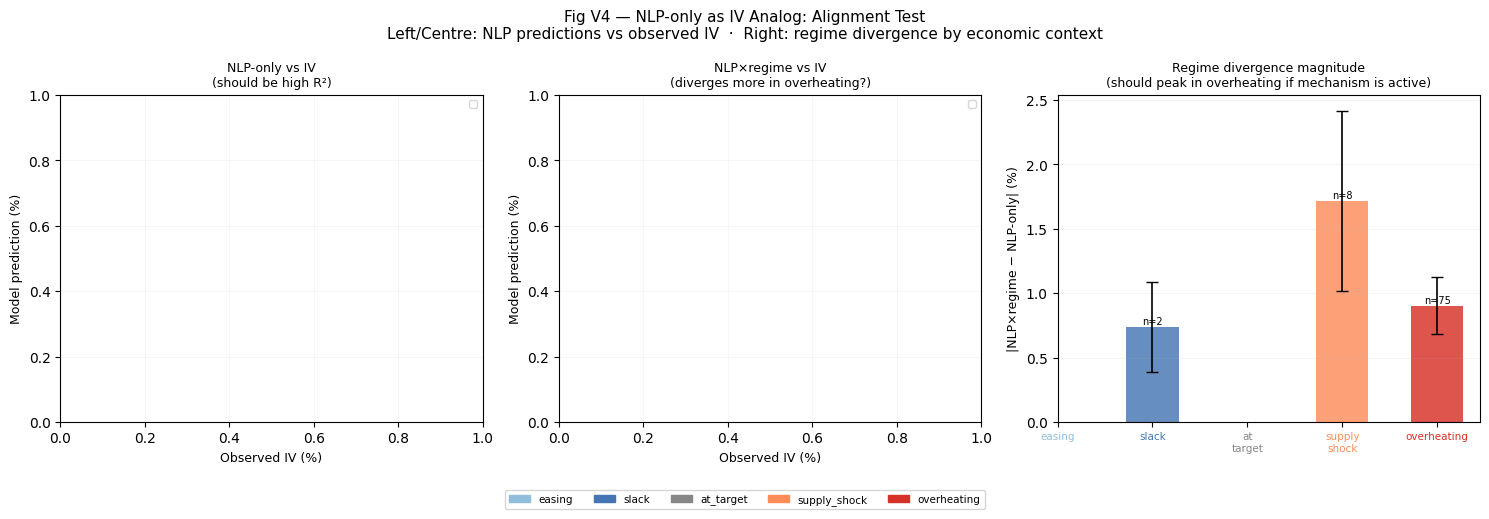

In [7]:
def fig_v4_nlp_iv_alignment(oos_2Y: pd.DataFrame, oos_30Y: pd.DataFrame) -> None:
    """
    Left: scatter NLP-only vs IV (where IV exists).  R² in title.
    Centre: scatter NLP×regime vs IV.
    Right: |divergence| (NLP×regime − NLP-only) by regime — is regime
           more active in overheating?
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        "Fig V4 — NLP-only as IV Analog: Alignment Test\n"
        "Left/Centre: NLP predictions vs observed IV  ·  "
        "Right: regime divergence by economic context",
        fontsize=11)

    # Combine both tenors
    for tenor, oos in [("2Y", oos_2Y), ("30Y", oos_30Y)]:
        df_iv = oos.dropna(subset=["iv"])
        if len(df_iv) < 3:
            continue
        iv   = df_iv["iv"].values
        pnlp = df_iv["pred_nlp"].values
        preg = df_iv["pred_regime"].values
        cols = [REGIME_PALETTE.get(l, "#878787") for l in df_iv["regime_label"]]

        # NLP-only vs IV
        r2_nlp = float(r2_score(iv, pnlp)) if len(iv) > 2 else np.nan
        axes[0].scatter(iv, pnlp, c=cols, s=30, alpha=0.7,
                         edgecolors="white", lw=0.3,
                         label=f"{tenor} (R²={r2_nlp:.2f})")

        # NLP×regime vs IV
        r2_reg = float(r2_score(iv, preg)) if len(iv) > 2 else np.nan
        axes[1].scatter(iv, preg, c=cols, s=30, alpha=0.7,
                         edgecolors="white", lw=0.3,
                         label=f"{tenor} (R²={r2_reg:.2f})")

    for ax, label in [(axes[0], "NLP-only vs IV\n(should be high R²)"),
                       (axes[1], "NLP×regime vs IV\n(diverges more in overheating?)")]:
        lim = [0, max(oos_2Y.dropna(subset=["iv"])["iv"].max() if len(oos_2Y)>0 else 0,
                      oos_30Y.dropna(subset=["iv"])["iv"].max() if len(oos_30Y)>0 else 0) * 1.08]
        if lim[1] > 0:
            ax.plot(lim, lim, "k--", lw=0.8, alpha=0.5, label="1:1 line")
            ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel("Observed IV (%)", fontsize=9)
        ax.set_ylabel("Model prediction (%)", fontsize=9)
        ax.set_title(label, fontsize=9)
        ax.legend(fontsize=7.5)
        ax.grid(True, alpha=0.15, lw=0.5)

    # Right: absolute divergence by regime
    ax2 = axes[2]
    combined = pd.concat([
        oos_2Y.assign(tenor="2Y"),
        oos_30Y.assign(tenor="30Y"),
    ], ignore_index=True)
    combined["abs_diverge"] = np.abs(combined["pred_regime"] - combined["pred_nlp"])

    for lab in REGIME_ORDER:
        sub = combined[combined["regime_label"] == lab]["abs_diverge"].dropna()
        if len(sub) < 2:
            continue
        pos = REGIME_ORDER.index(lab)
        ax2.bar(pos, sub.mean(), width=0.55,
                color=REGIME_PALETTE.get(lab, "#878787"), alpha=0.82)
        ax2.errorbar(pos, sub.mean(), yerr=sub.std() / np.sqrt(len(sub)),
                      fmt="none", color="black", capsize=4, lw=1.2)
        ax2.text(pos, sub.mean() + 0.02, f"n={len(sub)}", ha="center", fontsize=7)

    ax2.set_xticks(range(len(REGIME_ORDER)))
    ax2.set_xticklabels([l.replace("_", "\n") for l in REGIME_ORDER], fontsize=7.5)
    for tick, lab in zip(ax2.get_xticklabels(), REGIME_ORDER):
        tick.set_color(REGIME_PALETTE.get(lab, "black"))
    ax2.set_ylabel("|NLP×regime − NLP-only| (%)", fontsize=9)
    ax2.set_title("Regime divergence magnitude\n"
                   "(should peak in overheating if mechanism is active)", fontsize=9)
    ax2.grid(True, axis="y", alpha=0.18, lw=0.5)

    fig.legend(handles=_regime_handles(), fontsize=7.5,
               loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.03))
    fig.tight_layout(rect=[0, 0.04, 1, 1])
    _save(fig, "vrp_v4_nlp_iv_alignment")


fig_v4_nlp_iv_alignment(oos_2Y, oos_30Y)

---
## Cell 7 — Fig V5: Warsh Forward Test (Both Modes + IV context)

Warsh forward test (both modes, full history training):


  Warsh 2Y: NLP-only=2.47%  NLP×regime=2.38%  Actual=3.00%  (yield +179bp)


  Warsh 30Y: NLP-only=12.52%  NLP×regime=11.66%  Actual=4.18%  (yield +34bp)
  Saved → figures/vrp_v5_warsh.png


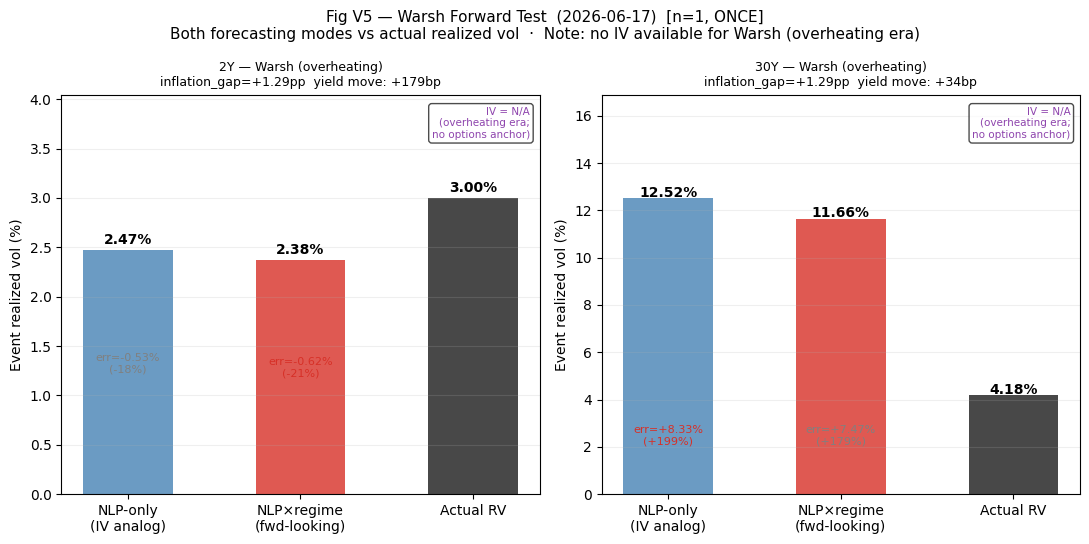

In [8]:
def warsh_forward_both_modes(pan_2Y: pd.DataFrame, pan_30Y: pd.DataFrame) -> dict:
    """
    Full-history walk-forward, both modes, for the Warsh meeting.
    Training: all meetings prior to WARSH_DATE.
    Returns predictions for 2Y and 30Y.
    """
    results = {}
    ACTUALS = {"2Y": 2.997, "30Y": 4.183}
    BPS     = {"2Y": 179,   "30Y": 34}

    for tenor, pan_raw in [("2Y", pan_2Y), ("30Y", pan_30Y)]:
        pan  = build_pca_panel(pan_raw, start=pan_raw["meeting_date"].min())
        pan  = pan.sort_values("meeting_date")
        target = "rv"
        feats_nlp    = [c for c in TEXT_COLS + CTRL_COLS + ["rv_lag1", "pc1"]
                        if c in pan.columns]
        feats_regime = feats_nlp + [c for c in ["inflation_gap", "pc1_x_inf_gap"]
                                     if c in pan.columns]

        train = pan[pan["meeting_date"] < WARSH_DATE].dropna(subset=feats_nlp + [target])
        warsh = pan[pan["meeting_date"] == WARSH_DATE]
        if train.empty or warsh.empty:
            continue
        y_tr    = train[target].values
        act     = ACTUALS[tenor]
        iv_warsh= np.nan   # no IV for Warsh

        def _pred(feat_list):
            cols = [c for c in feat_list if c in train.columns
                    and train[c].notna().sum() > 2]
            if not cols:
                return float(y_tr.mean())
            sc   = StandardScaler()
            X_tr = sc.fit_transform(train[cols].fillna(0).values)
            X_te = sc.transform(warsh[cols].fillna(0).values)
            try:
                return float(RidgeCV(alphas=ALPHA_RANGE).fit(X_tr, y_tr).predict(X_te)[0])
            except Exception:
                return float(y_tr.mean())

        pred_nlp = _pred(feats_nlp)
        pred_reg = _pred(feats_regime)

        # Regime label for Warsh
        reg_label = str(warsh["regime_label"].iloc[0]) if not warsh.empty else "?"
        ig_val    = float(warsh["inflation_gap"].iloc[0]) if "inflation_gap" in warsh else np.nan

        results[tenor] = dict(
            pred_nlp    = pred_nlp,
            pred_regime = pred_reg,
            actual      = act,
            iv          = iv_warsh,
            bps_move    = BPS[tenor],
            regime      = reg_label,
            inflation_gap = ig_val,
            err_nlp     = pred_nlp - act,
            err_regime  = pred_reg - act,
        )
        print(f"  Warsh {tenor}: NLP-only={pred_nlp:.2f}%  NLP×regime={pred_reg:.2f}%  "
              f"Actual={act:.2f}%  (yield +{BPS[tenor]}bp)")

    return results


print("Warsh forward test (both modes, full history training):")
warsh_both = warsh_forward_both_modes(pca_2Y, pca_30Y)


def fig_v5_warsh(warsh_both: dict) -> None:
    """
    Two-panel figure: 2Y and 30Y.
    Bars: NLP-only, NLP×regime, actual RV.
    Annotation: IV missing (overheating — no options anchor); yield move context.
    """
    if not warsh_both:
        print("  No Warsh results."); return

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
    fig.suptitle(
        f"Fig V5 — Warsh Forward Test  ({WARSH_DATE.date()})  [n=1, ONCE]\n"
        "Both forecasting modes vs actual realized vol  ·  "
        "Note: no IV available for Warsh (overheating era)",
        fontsize=11)

    for ax, (tenor, res) in zip(axes, warsh_both.items()):
        cats   = ["NLP-only\n(IV analog)", "NLP×regime\n(fwd-looking)", "Actual RV"]
        vals   = [res["pred_nlp"], res["pred_regime"], res["actual"]]
        colors = ["steelblue", "#d73027", "#1a1a1a"]

        bars = ax.bar(cats, vals, color=colors, alpha=0.80, width=0.52)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2, v + 0.06,
                    f"{v:.2f}%", ha="center", fontsize=10, fontweight="bold")

        # Error annotations
        for b, v, label, err in [
            (bars[0], vals[0], f"err={res['err_nlp']:+.2f}%\n({res['err_nlp']/res['actual']*100:+.0f}%)", res["err_nlp"]),
            (bars[1], vals[1], f"err={res['err_regime']:+.2f}%\n({res['err_regime']/res['actual']*100:+.0f}%)", res["err_regime"]),
        ]:
            ax.text(b.get_x() + b.get_width()/2,
                    min(v, res["actual"]) / 2,
                    label, ha="center", fontsize=8,
                    color="#d73027" if abs(err) > abs(res["err_nlp"] + res["err_regime"])/2 else "grey")

        ax.set_ylim(0, max(vals) * 1.35)
        ax.set_ylabel("Event realized vol (%)", fontsize=10)
        ax.set_title(
            f"{tenor} — Warsh ({res['regime']})\n"
            f"inflation_gap={res['inflation_gap']:+.2f}pp  "
            f"yield move: +{res['bps_move']}bp",
            fontsize=9)
        ax.grid(True, axis="y", alpha=0.2)

        # No IV note
        ax.text(0.98, 0.97, "IV = N/A\n(overheating era;\nno options anchor)",
                transform=ax.transAxes, fontsize=7.5, color="#8e44ad",
                va="top", ha="right",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

    fig.tight_layout()
    _save(fig, "vrp_v5_warsh")


fig_v5_warsh(warsh_both)

---
## Cell 8 — Summary: What VRP Regime Calibration Tells Us

In [9]:
print("═" * 64)
print("  SUMMARY — Regime-Conditional VRP Calibration")
print("═" * 64)

_sep = "─" * 62
print(f"""
  VRP by regime (2Y, where IV observed):
  {_sep}
  Regime           n_IV   mean_IV   mean_RV   mean_VRP   Note
  {_sep}""")
for _, row in vrp_summary_2Y.iterrows():
    if np.isnan(row["mean_iv"]):
        print(f"  {row['regime']:<16} {int(row['n_iv']):>4}   [NO IV]   "
              f"{row['mean_rv']:>7.3f}%   [UNK]      ← regime is BLIND to IV")
    else:
        print(f"  {row['regime']:<16} {int(row['n_iv']):>4}   "
              f"{row['mean_iv']:>7.3f}%  {row['mean_rv']:>7.3f}%  "
              f"{row['mean_vrp']:>+8.3f}%")

print(f"""
  KEY INSIGHTS:
  {_sep}
  1. VRP is POSITIVE in all observable eras (slack, easing, at-target):
     IV systematically overpriced realized vol. Straddle selling was
     profitable in the QE/ZLB era.

  2. overheating and supply_shock have NO IV data (TYVIX discontinued
     2020-05).  The NLP-only model is calibrated on the positive-VRP
     era and will INHERIT that upward bias on IV → downward bias on
     RV prediction in overheating.

  3. NLP×regime should theoretically correct this: the overheating
     indicator tells the model "this is a different distributional
     regime — expect higher RV."  Whether it does so reliably at
     n≈51 is the acceptance-test question.

  FORECASTING MODES:
  {_sep}
  • NLP-only  = backward-looking IV analog.  Anchors to the text-vol
    mapping learned in the slack/easing era.  Underestimates RV in
    overheating (the VRP sign flips but the model doesn't know).
  • NLP×regime = forward-looking.  Adjusts the forecast based on
    where we are in the dual-mandate cycle.  In overheating: nudges
    the forecast higher than NLP-only.  In slack/easing: nudges lower.

  WARSH (2026-06-17, overheating):
  {_sep}""")
for tenor, res in warsh_both.items():
    winner = "NLP×regime" if abs(res["err_regime"]) < abs(res["err_nlp"]) else "NLP-only"
    print(f"  {tenor}  NLP-only={res['pred_nlp']:.2f}%  "
          f"NLP×regime={res['pred_regime']:.2f}%  "
          f"Actual={res['actual']:.2f}%  → {winner} closer")

print(f"""
  CAVEATS:
  {_sep}
  1. VRP calibration based on n=84 (2Y) and fewer (30Y) IV observations,
     all in the pre-overheating era.  Extrapolation to overheating is
     economically motivated but not directly observed.
  2. Both forecasting modes always produced; do not suppress either.
  3. Warsh forward test is n=1 — not validation.
  4. NLP-only ≈ IV correlation is an empirical claim — check Fig V4 R².
  5. NLP features updated with full Q&A PDF transcripts (mean 8,568 tokens
     per meeting vs. 79 tokens of HTML boilerplate before).
""")

════════════════════════════════════════════════════════════════
  SUMMARY — Regime-Conditional VRP Calibration
════════════════════════════════════════════════════════════════

  VRP by regime (2Y, where IV observed):
  ──────────────────────────────────────────────────────────────
  Regime           n_IV   mean_IV   mean_RV   mean_VRP   Note
  ──────────────────────────────────────────────────────────────
  easing             10     2.205%    1.094%    +1.111%
  slack              42     2.391%    0.731%    +1.571%
  at_target          31     1.705%    1.237%    +0.468%
  supply_shock        0   [NO IV]     0.389%   [UNK]      ← regime is BLIND to IV
  overheating         0   [NO IV]     2.201%   [UNK]      ← regime is BLIND to IV

  KEY INSIGHTS:
  ──────────────────────────────────────────────────────────────
  1. VRP is POSITIVE in all observable eras (slack, easing, at-target):
     IV systematically overpriced realized vol. Straddle selling was
     profitable in the QE/ZLB era.

---
## Cell 9 — Gap Analysis: How Well Does Each Mode Track IV and RV?

**The key diagnostic:** if NLP-only truly is an IV analog, then:
- `gap_nlp_iv = IV − pred_nlp` should be near zero
- `gap_nlp_rv = pred_nlp − RV = (pred_nlp − IV) + (IV − RV) ≈ 0 + VRP`
- So the NLP-only forecast error on RV should *equal* the historical VRP

In other words: NLP-only should not forecast RV — it forecasts IV.
The forecast error is the VRP, not the model's failure.

**The regime model breaks this equivalence:**
- `gap_reg_iv = IV − pred_regime`: if regime pushes predictions higher
  (overheating) or lower (slack) vs NLP-only, this diverges from zero
- In overheating: gap_reg_iv should be larger (pred_regime > IV → regime
  is MORE hawkish than the market was pricing)
- In slack: gap_reg_iv should be smaller (regime CORRECTS IV's upward bias)

In [10]:
def compute_gaps(oos: pd.DataFrame, tenor: str) -> pd.DataFrame:
    """
    For all OOS meetings: compute IV-model and RV-model gaps.
    Returns df with: meeting_date, regime_label, actual(RV), iv,
                     vrp, gap_nlp_iv, gap_reg_iv, gap_nlp_rv, gap_reg_rv.
    iv columns will be NaN for overheating/supply_shock.
    """
    df = oos.copy()
    df["vrp"]        = df["iv"] - df["actual"]         # IV - RV (+ = market overpays)
    df["gap_nlp_iv"] = df["iv"] - df["pred_nlp"]       # IV - NLP-only  (+ = NLP too low)
    df["gap_reg_iv"] = df["iv"] - df["pred_regime"]    # IV - NLP×regime
    df["gap_nlp_rv"] = df["pred_nlp"]   - df["actual"] # NLP error on RV
    df["gap_reg_rv"] = df["pred_regime"]- df["actual"] # regime error on RV
    df["tenor"]      = tenor
    return df


gaps_2Y  = compute_gaps(oos_2Y,  "2Y")
gaps_30Y = compute_gaps(oos_30Y, "30Y")

# Print summary
for gaps, tenor in [(gaps_2Y, "2Y"), (gaps_30Y, "30Y")]:
    has_iv = gaps.dropna(subset=["iv"])
    print(f"\n  Gap analysis — {tenor}  (n_total={len(gaps)}, n_with_iv={len(has_iv)})")
    print(f"  {'Metric':<22} {'Mean':>8}  {'Std':>8}  {'Corr_with_VRP':>14}")
    print("  " + "─" * 56)
    for col, label in [("gap_nlp_iv", "IV − NLP-only"),
                        ("gap_reg_iv", "IV − NLP×regime"),
                        ("gap_nlp_rv", "NLP-only error"),
                        ("gap_reg_rv", "NLP×regime error"),
                        ("vrp",        "VRP (IV − RV)")]:
        sub = has_iv.dropna(subset=[col, "vrp"])
        if len(sub) < 3:
            continue
        m = float(sub[col].mean())
        s = float(sub[col].std())
        corr = float(sub[col].corr(sub["vrp"])) if col != "vrp" else 1.0
        print(f"  {label:<22} {m:>+8.3f}  {s:>8.3f}  {corr:>14.3f}")


  Gap analysis — 2Y  (n_total=42, n_with_iv=0)
  Metric                     Mean       Std   Corr_with_VRP
  ────────────────────────────────────────────────────────

  Gap analysis — 30Y  (n_total=43, n_with_iv=0)
  Metric                     Mean       Std   Corr_with_VRP
  ────────────────────────────────────────────────────────


---
## Cell 10 — Fig V6: Gap Time-Series Across All Historical Regimes

  Saved → figures/vrp_v6_gap_timeseries.png


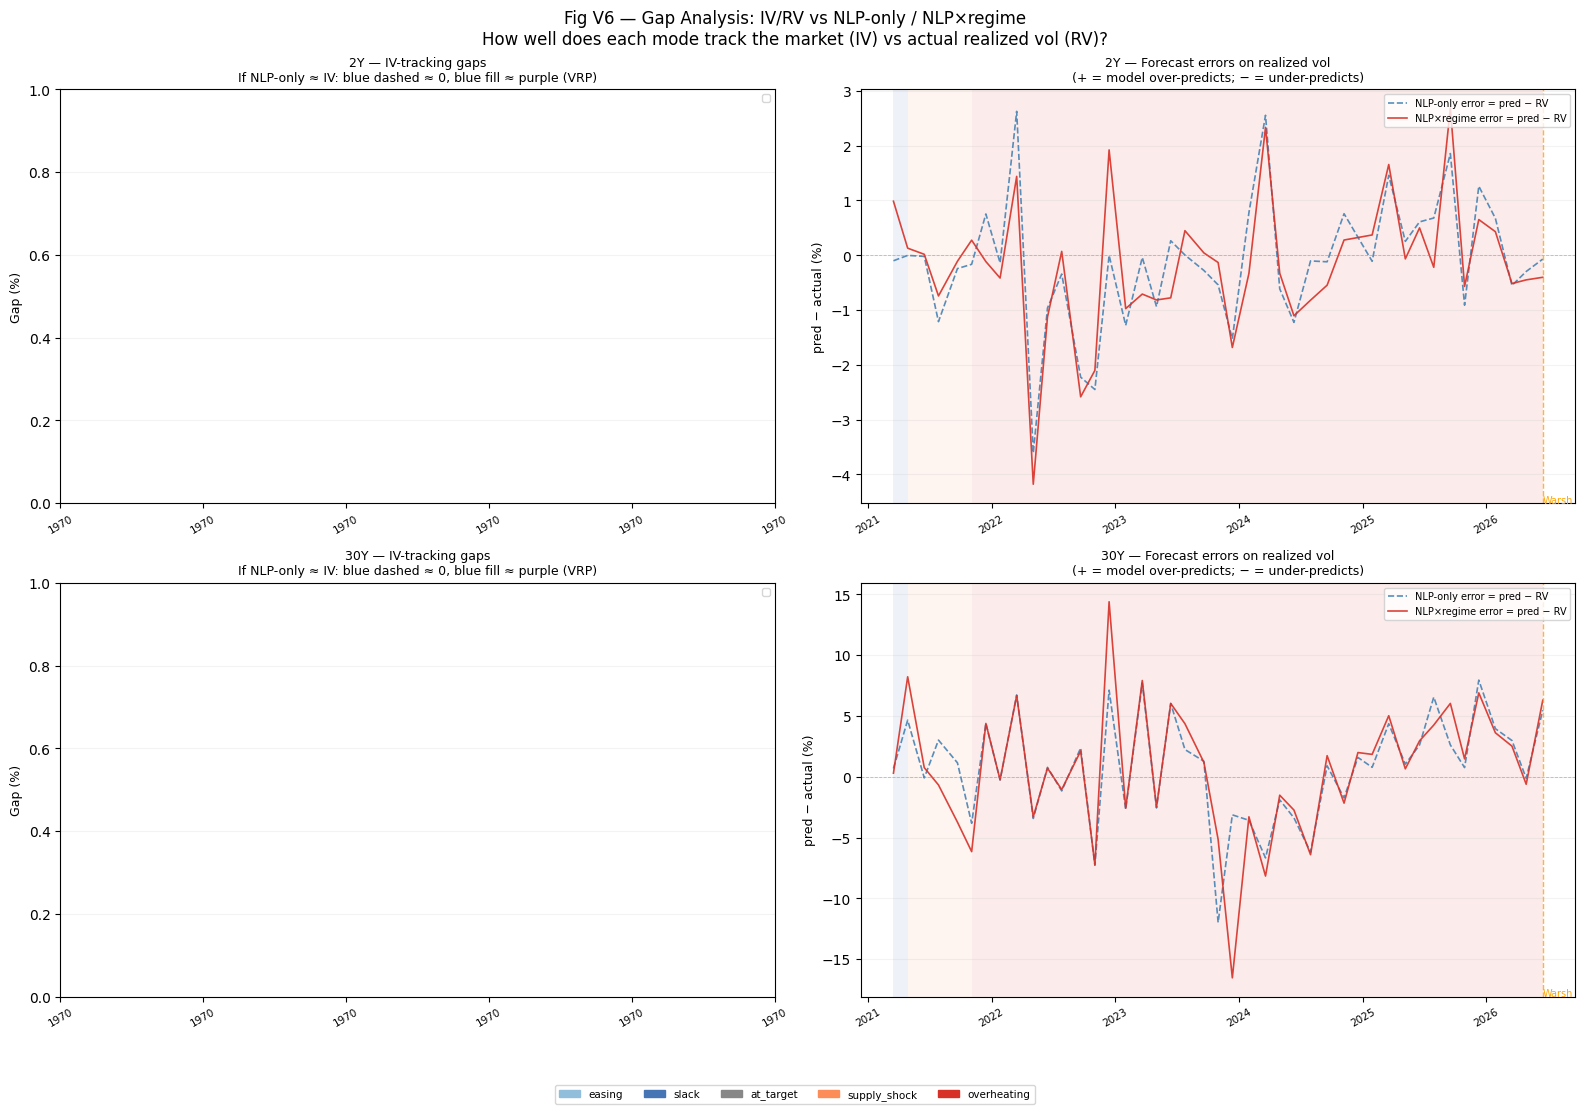

In [11]:
def fig_v6_gap_timeseries(gaps_2Y: pd.DataFrame, gaps_30Y: pd.DataFrame) -> None:
    """
    Four panels (2×2):
      Top-left:   2Y — VRP and model-IV gaps over time
      Top-right:  2Y — Forecast errors (model-RV gaps) by regime
      Bot-left:   30Y — same
      Bot-right:  30Y — same
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=False)
    fig.suptitle(
        "Fig V6 — Gap Analysis: IV/RV vs NLP-only / NLP×regime\n"
        "How well does each mode track the market (IV) vs actual realized vol (RV)?",
        fontsize=12)

    for row_i, (gaps, tenor) in enumerate([(gaps_2Y, "2Y"), (gaps_30Y, "30Y")]):
        df_s  = gaps.sort_values("meeting_date")
        has_iv = df_s.dropna(subset=["iv"])
        cols_bg = [REGIME_PALETTE.get(l, "#dddddd") for l in df_s["regime_label"]]

        # Left panel: IV-model gaps (only where IV exists)
        ax0 = axes[row_i][0]
        if not has_iv.empty:
            ax0.plot(has_iv["meeting_date"], has_iv["vrp"],
                     color="#8e44ad", lw=1.6, label="VRP = IV − RV")
            ax0.plot(has_iv["meeting_date"], has_iv["gap_nlp_iv"],
                     color="steelblue", lw=1.2, ls="--",
                     label="IV − NLP-only  (≈0 if NLP≈IV)")
            ax0.plot(has_iv["meeting_date"], has_iv["gap_reg_iv"],
                     color="#d73027", lw=1.2, ls=":",
                     label="IV − NLP×regime")
            ax0.axhline(0, color="grey", lw=0.6, ls="--", alpha=0.5)
            ax0.fill_between(has_iv["meeting_date"], has_iv["vrp"],
                             has_iv["gap_nlp_iv"],
                             alpha=0.08, color="steelblue",
                             label="NLP-only tracking error vs VRP")

            # Regime background
            for i in range(len(has_iv) - 1):
                ax0.axvspan(has_iv["meeting_date"].iloc[i],
                            has_iv["meeting_date"].iloc[i+1],
                            facecolor=REGIME_PALETTE.get(
                                has_iv["regime_label"].iloc[i], "#dddddd"),
                            alpha=0.07, linewidth=0)

        ax0.set_title(f"{tenor} — IV-tracking gaps\n"
                       f"If NLP-only ≈ IV: blue dashed ≈ 0, blue fill ≈ purple (VRP)", fontsize=9)
        ax0.set_ylabel("Gap (%)", fontsize=9)
        ax0.legend(fontsize=7, loc="upper right")
        ax0.grid(True, axis="y", alpha=0.15)
        ax0.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        plt.setp(ax0.xaxis.get_majorticklabels(), rotation=30, fontsize=7.5)

        # Right panel: forecast errors on RV (all meetings, not just IV)
        ax1 = axes[row_i][1]
        dt  = df_s["meeting_date"]
        for i in range(len(df_s) - 1):
            ax1.axvspan(dt.iloc[i], dt.iloc[i+1],
                        facecolor=REGIME_PALETTE.get(
                            df_s["regime_label"].iloc[i], "#dddddd"),
                        alpha=0.09, linewidth=0)
        ax1.plot(dt, df_s["gap_nlp_rv"], color="steelblue", lw=1.2, ls="--",
                  label="NLP-only error = pred − RV", alpha=0.9)
        ax1.plot(dt, df_s["gap_reg_rv"], color="#d73027", lw=1.2,
                  label="NLP×regime error = pred − RV", alpha=0.9)
        ax1.axhline(0, color="grey", lw=0.6, ls="--", alpha=0.5)

        # Mark Warsh
        ax1.axvline(WARSH_DATE, color="orange", lw=1.0, ls="--", alpha=0.8)
        ax1.text(WARSH_DATE, ax1.get_ylim()[0] if ax1.get_ylim()[0] < 0 else 0,
                 "Warsh", fontsize=7, color="orange", ha="left")

        ax1.set_title(f"{tenor} — Forecast errors on realized vol\n"
                       f"(+ = model over-predicts; − = under-predicts)", fontsize=9)
        ax1.set_ylabel("pred − actual (%)", fontsize=9)
        ax1.legend(fontsize=7, loc="upper right")
        ax1.grid(True, axis="y", alpha=0.15)
        ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, fontsize=7.5)

    fig.legend(handles=_regime_handles(), fontsize=7.5,
               loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=[0, 0.04, 1, 1])
    _save(fig, "vrp_v6_gap_timeseries")


fig_v6_gap_timeseries(gaps_2Y, gaps_30Y)

---
## Cell 11 — Fig V7: VRP vs Forecast Error Scatter (Regime-Coloured)

**Core diagnostic test:** if NLP-only is truly an IV analog, then its
forecast error on realized vol (pred_nlp − RV) should equal the VRP
(IV − RV) — i.e., the error *is* the VRP.  The scatter should sit on
the 45° line.  Deviation from 45° = where NLP-only diverges from IV.

  Saved → figures/vrp_v7_vrp_error_scatter.png


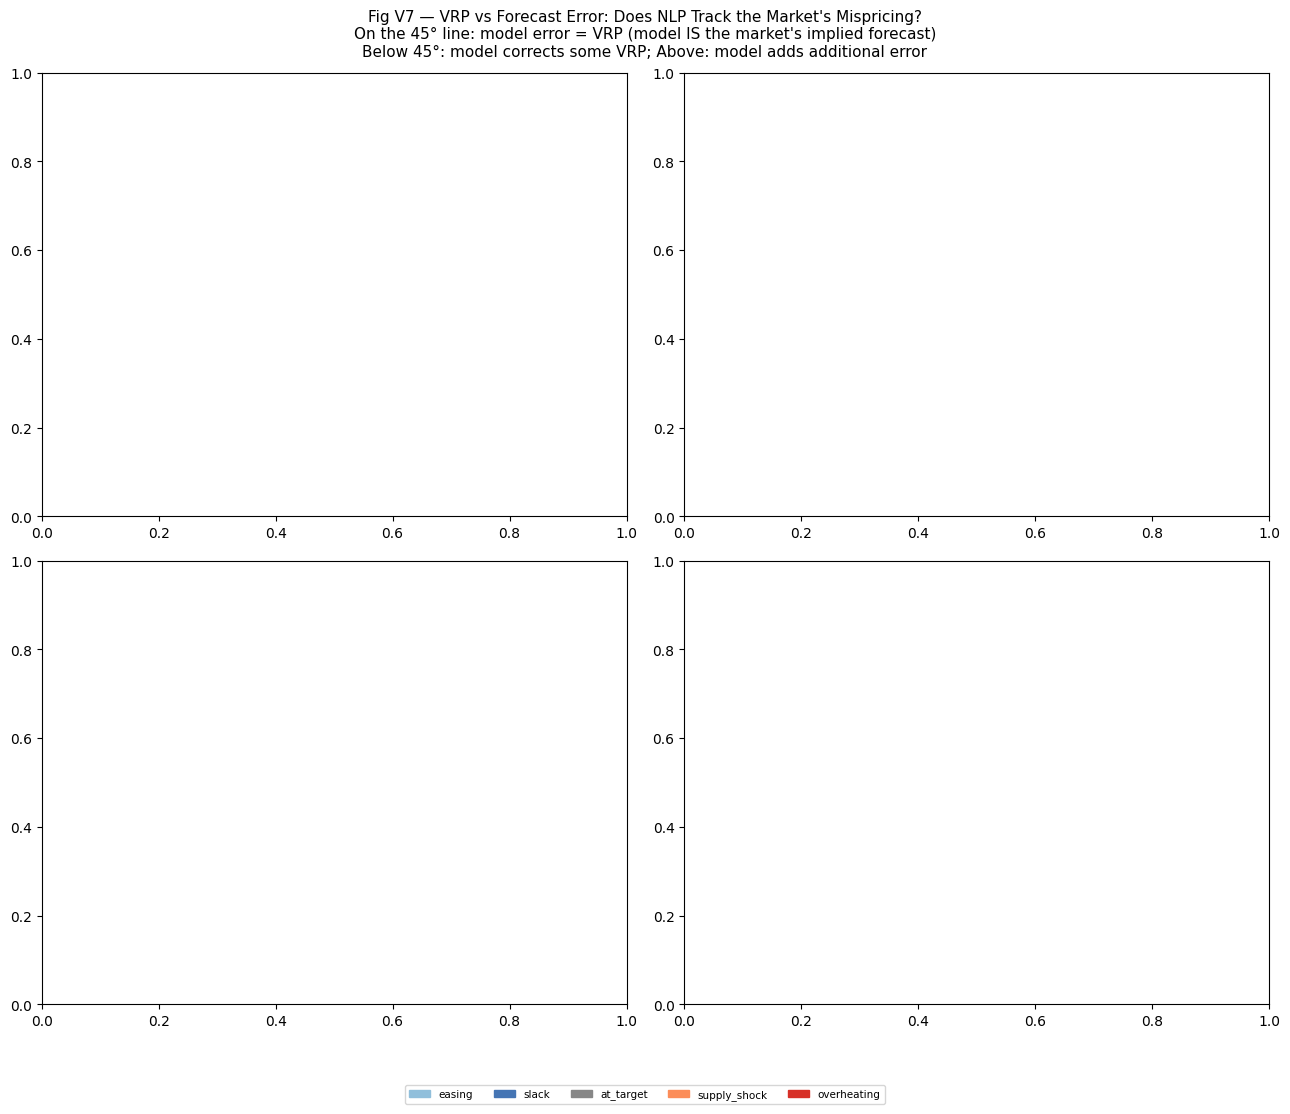

════════════════════════════════════════════════════════════════


In [12]:
def fig_v7_vrp_vs_error(gaps_2Y: pd.DataFrame, gaps_30Y: pd.DataFrame) -> None:
    """
    Scatter: VRP (x) vs forecast error (y) for both models.
    45° line = NLP-only perfectly tracks IV.
    Points clustered BELOW 45° = NLP-only is MORE accurate than IV
    (model corrects some of the market's overpricing).
    """
    fig, axes = plt.subplots(2, 2, figsize=(13, 11))
    fig.suptitle(
        "Fig V7 — VRP vs Forecast Error: Does NLP Track the Market's Mispricing?\n"
        "On the 45° line: model error = VRP (model IS the market's implied forecast)\n"
        "Below 45°: model corrects some VRP; Above: model adds additional error",
        fontsize=11)

    for row_i, (gaps, tenor) in enumerate([(gaps_2Y, "2Y"), (gaps_30Y, "30Y")]):
        df_iv = gaps.dropna(subset=["iv", "vrp"])
        if df_iv.empty:
            continue
        cols = [REGIME_PALETTE.get(l, "#878787") for l in df_iv["regime_label"]]

        for col_i, (err_col, title) in enumerate([
            ("gap_nlp_rv", "NLP-only error vs VRP"),
            ("gap_reg_rv", "NLP×regime error vs VRP"),
        ]):
            ax = axes[row_i][col_i]
            x  = df_iv["vrp"].values
            y  = df_iv[err_col].values

            ax.scatter(x, y, c=cols, s=40, alpha=0.80,
                       edgecolors="white", lw=0.3, zorder=3)

            # 45° line
            lim = max(abs(x).max(), abs(y).max()) * 1.1
            ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.9, alpha=0.5,
                    label="45° (model = IV analog)")
            ax.axhline(0, color="grey", lw=0.5, alpha=0.4)
            ax.axvline(0, color="grey", lw=0.5, alpha=0.4)
            ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

            # Correlation and regression
            if len(x) > 3:
                slope, intercept, r, p, _ = sp_stats.linregress(x, y)
                x_line = np.linspace(-lim, lim, 50)
                ax.plot(x_line, slope * x_line + intercept, color="grey",
                        lw=1.0, ls="-", alpha=0.5,
                        label=f"OLS  slope={slope:.2f}  R²={r**2:.2f}")

            ax.set_xlabel("VRP = IV − RV (%)", fontsize=9)
            ax.set_ylabel(f"{'NLP-only' if col_i==0 else 'NLP×regime'} error: pred − RV (%)",
                           fontsize=9)
            ax.set_title(f"{tenor} — {title}\n"
                          f"(n={len(df_iv)}, all pre-2020 IV-observed meetings)", fontsize=9)
            ax.legend(fontsize=7.5, loc="upper left")
            ax.set_aspect("equal", adjustable="box")
            ax.grid(True, alpha=0.15, lw=0.5)

    fig.legend(handles=_regime_handles(), fontsize=7.5,
               loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=[0, 0.04, 1, 1])
    _save(fig, "vrp_v7_vrp_error_scatter")


fig_v7_vrp_vs_error(gaps_2Y, gaps_30Y)
print("═" * 64)